# Hopf Oscillator with Heteroscedastic Noise and Weak SINDy + GLS

We consider the planar Hopf normal form

\begin{aligned}
\dot x &= \mu x - \omega y - (x^2 + y^2)\,x, \\
\dot y &= \omega x + \mu y - (x^2 + y^2)\,y,
\end{aligned}

with parameters $\mu > 0, \omega > 0$.

In polar coordinates $r^2 = x^2 + y^2$, the dynamics become

\begin{aligned}
\dot r &= \mu r - r^3, \\ 
\dot \theta &= \omega ,
\end{aligned}

so that the system has a stable limit cycle at radius
$r^\star = \sqrt{\mu}$ (here $\mu = 1$, so $r^\star = 1$).

We will:

1. Simulate a clean trajectory $U(t) = [x(t), y(t)]^\top$.
2. Add heteroscedastic noise whose variance depends on distance to the limit cycle.
3. Fit three weak SINDy models:
   - no weighting,
   - GLS weighting based on the noise variance,
   - GLS weighting with unit weights (test-function normalization).
4. Compare coefficient errors (relative $L_1$ and support $L_0$) at the ensemble level.
5. Run a forecast experiment from a new initial condition.
6. Run a Monte Carlo experiment over many initial conditions.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from tqdm import tqdm

import pysindy as ps
from pysindy.feature_library import WeakPDELibrary, WeightedWeakPDELibrary

# Set global plotting style
plt.rcParams.update({"font.family": "serif", "font.size": 12})


## 1. Hopf System and True Coefficients


In [2]:
# ------------------------------------------------------------
# Hopf oscillator (normal form)
# ------------------------------------------------------------
def hopf(t, u, mu=1.0, omega=1.0):
    x, y = u
    r2 = x**2 + y**2
    return np.array([
        mu * x - omega * y - r2 * x,
        omega * x + mu * y - r2 * y,
    ])


# True coefficients in the polynomial basis
# Basis ordering (degree 3, no bias) is:
# [x, y, x^2, x y, y^2, x^3, x^2 y, x y^2, y^3]
mu = 1.0
omega = 1.0

true_coef_hopf = np.array([
    [mu,    -omega, 0, 0, 0, -1, 0, -1, 0],   # x'
    [omega,  mu,    0, 0, 0,  0, -1, 0, -1],  # y'
])


## 2. Training Trajectory and Heteroscedastic Noise

We simulate a single training trajectory from a fixed initial condition.

For the Hopf oscillator, the limit cycle has radius $r^\star = 1$.
We model noise whose variance increases with the distance from the limit cycle:

\begin{aligned}
r(t) &= \|U(t)\|_2, \\
d(t) &= |r(t) - 1|, \\
\sigma^2(t) &= \bigl(\sigma_0 + \alpha\, d(t)\bigr)^2.
\end{aligned}

Noisy observations:
$$
U_{\text{noisy}}(t) = U(t) + \varepsilon(t), \quad
\varepsilon(t) \sim \mathcal N(0,\,\sigma^2(t) I_2).
$$

Training trajectory shape: (10000, 2)
Noise std range: 0.010000007589791296 to 0.13878679656440357


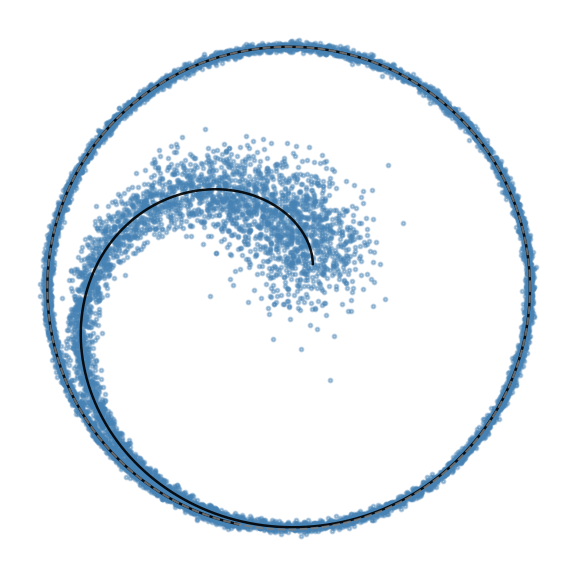

In [3]:
# ------------------------------------------------------------
# Simulation (training trajectory)
# ------------------------------------------------------------
t0, t1 = 0.0, 10.0
dt = 1e-3
t_eval = np.arange(t0, t1, dt)

rng = np.random.default_rng(0)

# Start inside, away from the limit cycle
u0 = np.array([0.1, 0.1])

sol = solve_ivp(
    hopf, (t0, t1), u0, t_eval=t_eval,
    rtol=1e-12, atol=1e-12
)
U = sol.y.T   # shape (T, 2)

print("Training trajectory shape:", U.shape)

# ------------------------------------------------------------
# Heteroscedastic noise based on distance from limit cycle (r=1)
# ------------------------------------------------------------
r = np.linalg.norm(U, axis=1)      # radius
d = np.abs(r - 1.0)                # distance from limit cycle

sigma0 = 1e-2
alpha = 0.15

variance = (sigma0 + alpha * d)**2
std = np.sqrt(variance)

noise = std[:, None] * rng.standard_normal(size=U.shape)
U_noisy = U + noise

print("Noise std range:", std.min(), "to", std.max())

# ------------------------------------------------------------
# Phase portrait: clean vs noisy, with limit cycle
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 4), dpi=150)

ax.plot(U[:, 0], U[:, 1],
        lw=1.2, color="black", alpha=0.9, label="clean")
ax.scatter(U_noisy[:, 0], U_noisy[:, 1],
           s=3, color="steelblue", alpha=0.4, label="noisy")

# Limit cycle r = 1
theta = np.linspace(0, 2*np.pi, 400)
ax.plot(np.cos(theta), np.sin(theta),
        "--", color="gray", linewidth=1.0, alpha=0.8, label="limit cycle")

ax.set_aspect("equal", "box")
ax.set_xticks([]); ax.set_yticks([])
ax.set_xlabel(""); ax.set_ylabel("")
# ax.legend(frameon=False, loc="upper right")
ax.set_frame_on(False)

plt.tight_layout()
plt.show()


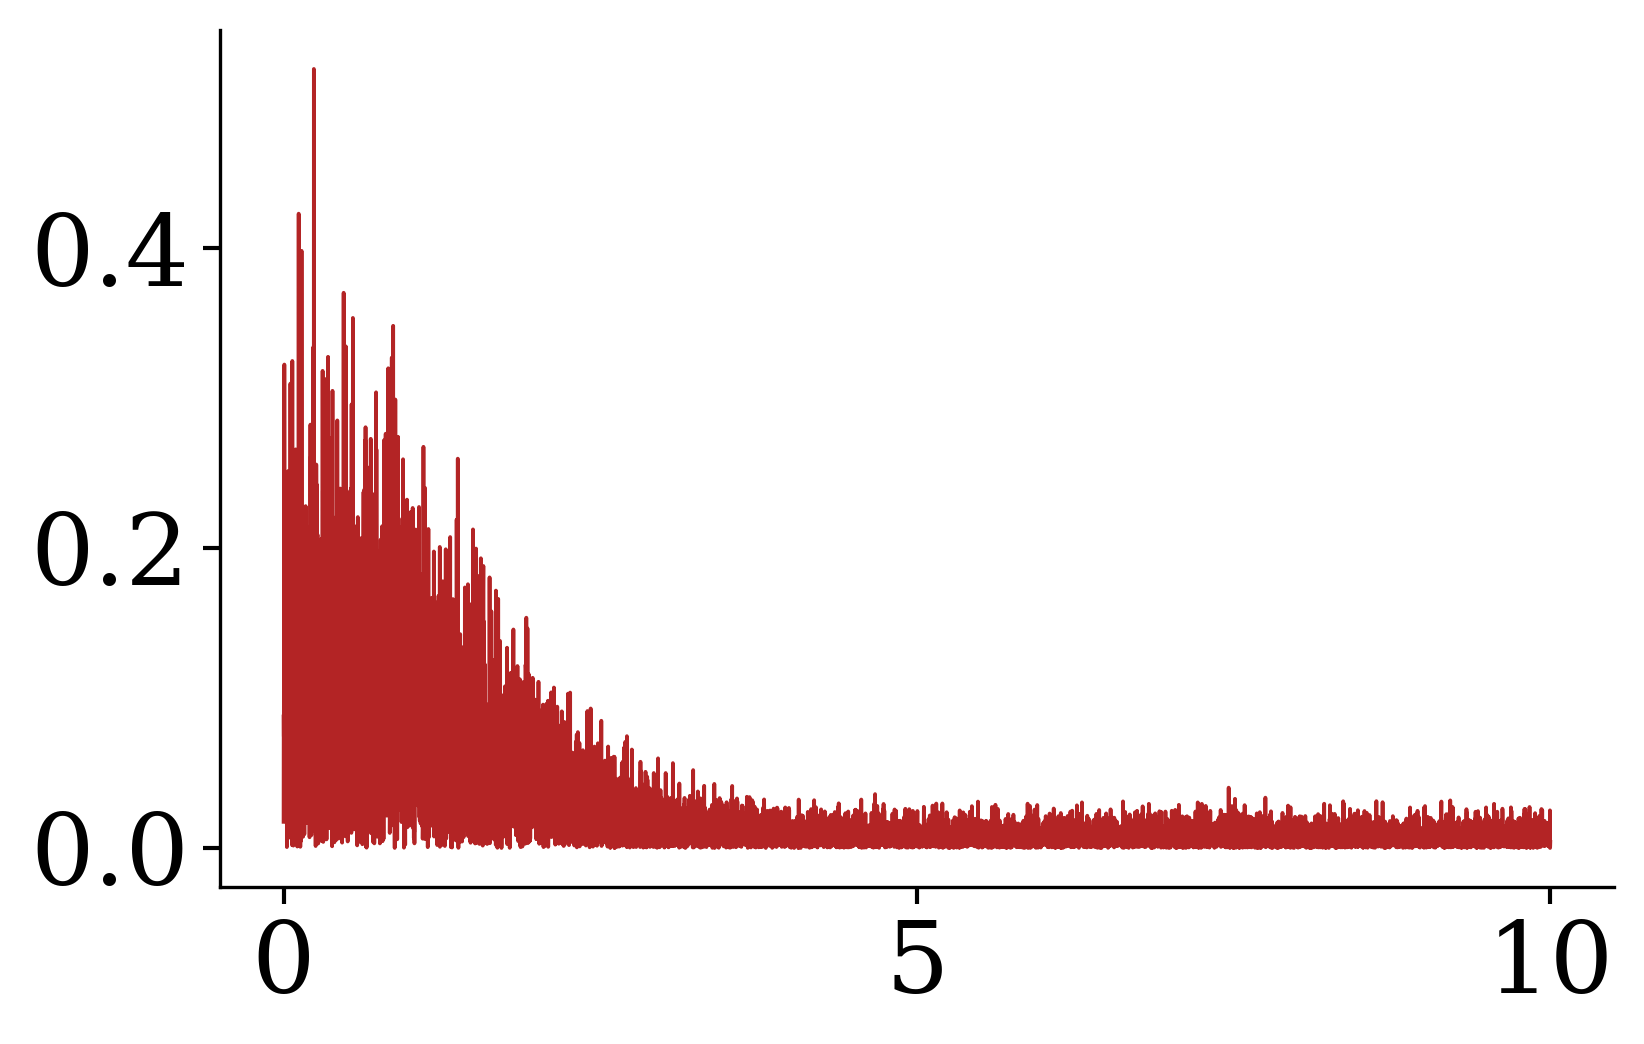

In [4]:
# ------------------------------------------------------------
# Residual plot for Lorenz x-component: |x_noisy - x_clean|
# ------------------------------------------------------------

x_clean = U[:, 0]
x_noisy = U_noisy[:, 0]

eps_x = np.abs(x_noisy - x_clean)

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 24,
})

steelred = "#b32425"   # same color style as theta residual plot

fig, ax = plt.subplots(figsize=(6, 4), dpi=300)

ax.plot(
    t_eval,          # use t_id if your time array is t_id
    eps_x,
    lw=0.9,
    color=steelred,
)

# ax.set_xlabel(r"$t\,[\mathrm{s}]$")
# ax.set_ylabel(r"$\|\varepsilon_x(t)\|$")

# Clean figure aesthetics
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="both", width=1.0, length=4)
ax.grid(False)

plt.tight_layout()
plt.show()


## 3. Weak SINDy Libraries and GLS Weighting

We construct three weak libraries:

- **No weighting**: standard weak SINDy.
- **Weighted Noise GLS**: GLS weighting based on the variance field $\sigma^2(t)$.
- **Weighted Test-function GLS**: GLS with constant weights (all ones),
  so only the test-function structure is used in the whitening.


In [5]:
# ------------------------------------------------------------
# Weak and weighted weak libraries
# ------------------------------------------------------------
XT = t_eval[:, None]               # "spatiotemporal grid" (time only)
spatiotemporal_weights = variance  # per-time variance field

base_library = ps.PolynomialLibrary(degree=3, include_bias=False)

weak_lib = WeakPDELibrary(
    function_library=base_library,
    derivative_order=1,
    spatiotemporal_grid=XT,
    is_uniform=True,
    include_bias=False,
)

weighted_weak_lib_noise = WeightedWeakPDELibrary(
    function_library=base_library,
    derivative_order=1,
    spatiotemporal_grid=XT,
    spatiotemporal_weights=spatiotemporal_weights,
    is_uniform=True,
    include_bias=False,
)

weighted_weak_lib_ones = WeightedWeakPDELibrary(
    function_library=base_library,
    derivative_order=1,
    spatiotemporal_grid=XT,
    spatiotemporal_weights=np.ones_like(spatiotemporal_weights),
    is_uniform=True,
    include_bias=False,
)


In [6]:
# ------------------------------------------------------------
# Ensemble optimizers and SINDy models
# ------------------------------------------------------------
opt_std   = ps.EnsembleOptimizer(ps.STLSQ(threshold=0.5),
                                 bagging=True, n_models=100)
opt_noise = ps.EnsembleOptimizer(ps.STLSQ(threshold=0.5),
                                 bagging=True, n_models=100)
opt_ones  = ps.EnsembleOptimizer(ps.STLSQ(threshold=0.5),
                                 bagging=True, n_models=100)

model_std = ps.SINDy(feature_library=weak_lib, optimizer=opt_std).fit(U_noisy, t=t_eval)
model_noise = ps.SINDy(feature_library=weighted_weak_lib_noise, optimizer=opt_noise).fit(U_noisy, t=t_eval)
model_ones  = ps.SINDy(feature_library=weighted_weak_lib_ones, optimizer=opt_ones).fit(U_noisy, t=t_eval)

print("\nWeak SINDy (no weighting):")
model_std.print()
print("\nWeighted Weak SINDy (noise GLS):")
model_noise.print()
print("\nWeighted Weak SINDy (test-function GLS, weights=1):")
model_ones.print()



Weak SINDy (no weighting):
(x0)' = 1.003 x0 + -1.001 x1 + -1.002 x0^3 + -1.001 x0 x1^2
(x1)' = 0.973 x0

Weighted Weak SINDy (noise GLS):
(x0)' = 1.010 x0 + -1.000 x1 + -1.010 x0^3 + -1.009 x0 x1^2
(x1)' = 1.000 x0 + 1.062 x1 + -1.063 x0^2 x1 + -1.062 x1^3

Weighted Weak SINDy (test-function GLS, weights=1):
(x0)' = 1.015 x0 + -1.000 x1 + -1.016 x0^3 + -1.013 x0 x1^2
(x1)' = 1.000 x0 + 1.073 x1 + -1.074 x0^2 x1 + -1.074 x1^3


In [7]:
# ------------------------------------------------------------
# Collect ensemble coefficient tensors
# ------------------------------------------------------------
coef_std   = np.stack(opt_std.coef_list,   axis=0)   # (E, 2, n_terms)
coef_noise = np.stack(opt_noise.coef_list, axis=0)
coef_ones  = np.stack(opt_ones.coef_list,  axis=0)

print("coef_std   shape:",   coef_std.shape)
print("coef_noise shape:",   coef_noise.shape)
print("coef_ones  shape:",   coef_ones.shape)


coef_std   shape: (100, 2, 9)
coef_noise shape: (100, 2, 9)
coef_ones  shape: (100, 2, 9)


In [8]:
# ------------------------------------------------------------
# Mean relative L1 error on nonzero true coefficients
# and L0 support error
# ------------------------------------------------------------
def relative_L1_error(C_est, C_true, tol_nz=1e-6, tol_rel=1e-8):
    """
    Mean relative L1 error over coefficients with |C_true| > tol_nz.
    """
    C_est = np.asarray(C_est).ravel()
    C_true = np.asarray(C_true).ravel()

    mask = np.abs(C_true) > tol_nz
    if not np.any(mask):
        return 0.0

    C_true_nz = C_true[mask]
    C_est_nz  = C_est[mask]
    denom = np.maximum(np.abs(C_true_nz), tol_rel)

    rel_err = np.abs(C_est_nz - C_true_nz) 
    return np.mean(rel_err)


def l0_support_error(C_est, C_true, tol_support=1e-6):
    """
    L0 support mismatch: number of indices where the support of C_est and C_true
    differs (false positives + false negatives).
    """
    C_est = np.asarray(C_est).ravel()
    C_true = np.asarray(C_true).ravel()

    supp_true = np.abs(C_true) > tol_support
    supp_est  = np.abs(C_est)  > tol_support

    # XOR of the supports
    return np.count_nonzero(supp_true ^ supp_est)


In [9]:
C_true_flat = true_coef_hopf.reshape(-1)

E, n_states, n_terms = coef_std.shape

rel_L1_std,   rel_L1_noise,   rel_L1_ones   = [], [], []
L0_std,       L0_noise,       L0_ones       = [], [], []

for e in range(E):
    C_e_std   = coef_std[e].reshape(-1)
    C_e_noise = coef_noise[e].reshape(-1)
    C_e_ones  = coef_ones[e].reshape(-1)

    # relative L1
    rel_L1_std.append(  relative_L1_error(C_e_std,   C_true_flat))
    rel_L1_noise.append(relative_L1_error(C_e_noise, C_true_flat))
    rel_L1_ones.append( relative_L1_error(C_e_ones,  C_true_flat))

    # L0 support error
    L0_std.append(  l0_support_error(C_e_std,   C_true_flat))
    L0_noise.append(l0_support_error(C_e_noise, C_true_flat))
    L0_ones.append( l0_support_error(C_e_ones,  C_true_flat))

rel_L1_std   = np.asarray(rel_L1_std)
rel_L1_noise = np.asarray(rel_L1_noise)
rel_L1_ones  = np.asarray(rel_L1_ones)

L0_std   = np.asarray(L0_std,   dtype=int)
L0_noise = np.asarray(L0_noise, dtype=int)
L0_ones  = np.asarray(L0_ones,  dtype=int)

print("Mean relative L1 (no weighting):     ", np.mean(rel_L1_std))
print("Mean relative L1 (noise GLS):        ", np.mean(rel_L1_noise))
print("Mean relative L1 (test-f GLS, ones): ", np.mean(rel_L1_ones))

print("Mean L0 support error (no weighting):     ", np.mean(L0_std))
print("Mean L0 support error (noise GLS):        ", np.mean(L0_noise))
print("Mean L0 support error (test-f GLS, ones): ", np.mean(L0_ones))


Mean relative L1 (no weighting):      0.4816030376366468
Mean relative L1 (noise GLS):         0.027058538950688896
Mean relative L1 (test-f GLS, ones):  0.033625878736880145
Mean L0 support error (no weighting):      3.78
Mean L0 support error (noise GLS):         0.0
Mean L0 support error (test-f GLS, ones):  0.0


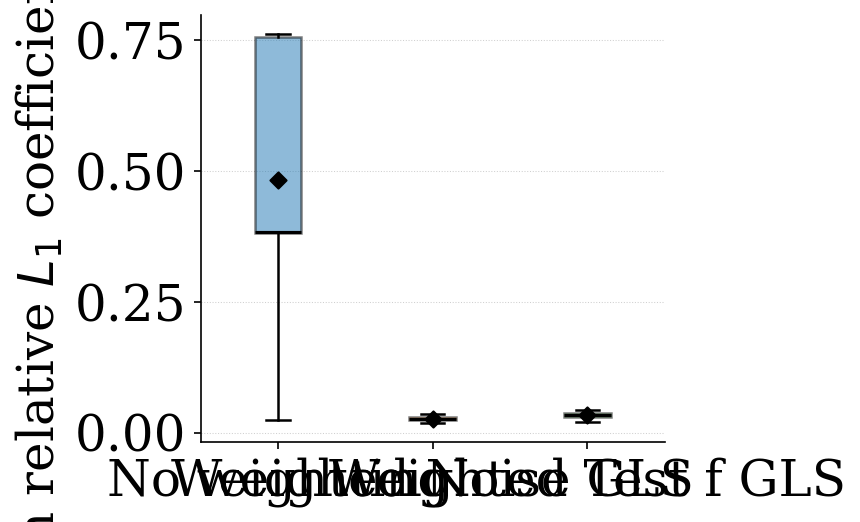

In [10]:
# ------------------------------------------------------------
# Boxplot of ensemble relative L1 errors
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 4), dpi=150)

data   = [rel_L1_std, rel_L1_noise, rel_L1_ones]
labels = ["No weighting", "Weighted Noise GLS", "Weighted Test f GLS"]
means  = [np.mean(d) for d in data]

bp = ax.boxplot(
    data,
    labels=labels,
    showfliers=False,
    patch_artist=True,
    medianprops=dict(color="black", linewidth=1.5),
    boxprops=dict(linewidth=1.2),
    whiskerprops=dict(linewidth=1.2),
    capprops=dict(linewidth=1.2),
)

colors = ["tab:blue", "tab:orange", "tab:green"]
for patch, c in zip(bp["boxes"], colors):
    patch.set_facecolor(c)
    patch.set_alpha(0.5)

# Mark means
for x, m in zip([1, 2, 3], means):
    ax.scatter(x, m, marker="D", color="black", s=30, zorder=3)

ax.set_ylabel(r"Mean relative $L_1$ coefficient error")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle=":", linewidth=0.5, alpha=0.6)

plt.tight_layout()
plt.show()


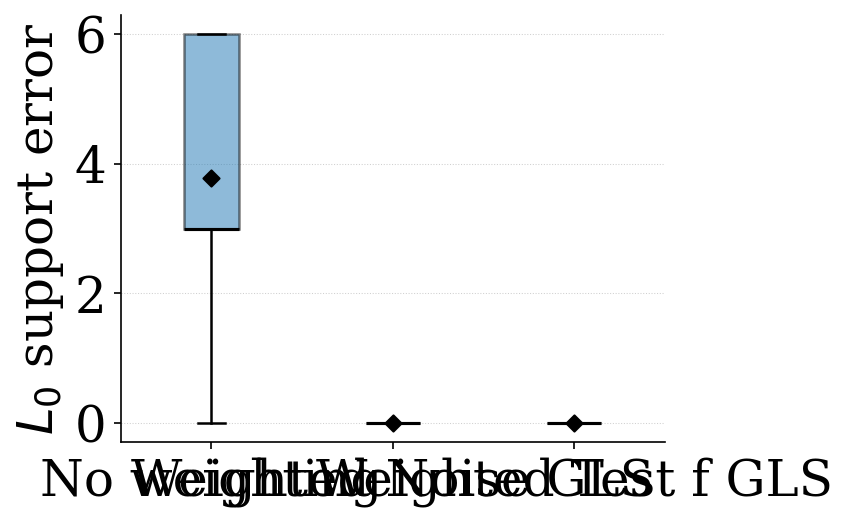

In [11]:
# ------------------------------------------------------------
# Boxplot of ensemble L0 support errors
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 4), dpi=150)

data_L0   = [L0_std, L0_noise, L0_ones]
labels_L0 = ["No weighting", "Weighted Noise GLS", "Weighted Test f GLS"]
means_L0  = [np.mean(d) for d in data_L0]

bp = ax.boxplot(
    data_L0,
    labels=labels_L0,
    showfliers=False,
    patch_artist=True,
    medianprops=dict(color="black", linewidth=1.5),
    boxprops=dict(linewidth=1.2),
    whiskerprops=dict(linewidth=1.2),
    capprops=dict(linewidth=1.2),
)

colors_L0 = ["tab:blue", "tab:orange", "tab:green"]
for patch, c in zip(bp["boxes"], colors_L0):
    patch.set_facecolor(c)
    patch.set_alpha(0.5)

for x, m in zip([1, 2, 3], means_L0):
    ax.scatter(x, m, marker="D", color="black", s=30, zorder=3)

ax.set_ylabel(r"$L_0$ support error")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle=":", linewidth=0.5, alpha=0.6)

plt.tight_layout()
plt.show()


## 5. Forecast Experiment from a New Initial Condition

We now build simulatable SINDy models from each ensemble member and forecast
from a new initial condition, comparing:

- the true Hopf trajectory,
- the mean trajectories of each method,
- the ensemble spread (±1σ).


In [12]:
# ------------------------------------------------------------
# Build simulatable models for each ensemble member
# ------------------------------------------------------------
sim_lib = ps.PolynomialLibrary(degree=3, include_bias=False)

def build_model(C):
    """
    Construct a SINDy model with fixed coefficients C (2 x n_terms).
    """
    m = ps.SINDy(feature_library=sim_lib)
    # Short dummy fit to allocate internal shapes
    m.fit(U_noisy[:200], t=t_eval[:200])
    m.optimizer.coef_ = C.copy()
    return m

models_std   = [build_model(C) for C in coef_std]
models_noise = [build_model(C) for C in coef_noise]
models_ones  = [build_model(C) for C in coef_ones]

print(f"Built {len(models_std)} std, {len(models_noise)} noise-weighted, {len(models_ones)} ones-weighted models.")


Built 100 std, 100 noise-weighted, 100 ones-weighted models.


In [13]:
# ------------------------------------------------------------
# Forecast from a new initial condition
# ------------------------------------------------------------
u0_pred = np.array([2.5, -1.0])
T_pred = 20.0
t_pred = np.arange(0.0, T_pred, dt)

sol_true = solve_ivp(
    hopf, (0.0, T_pred), u0_pred, t_eval=t_pred,
    rtol=1e-12, atol=1e-12
)
traj_true = sol_true.y.T  # (T_pred, 2)

def safe_sim(model):
    try:
        out = model.simulate(u0_pred, t_pred)
        if np.all(np.isfinite(out)):
            return out
    except Exception:
        pass
    return None

traj_std   = np.array([x for x in (safe_sim(m) for m in models_std)   if x is not None])
traj_noise = np.array([x for x in (safe_sim(m) for m in models_noise) if x is not None])
traj_ones  = np.array([x for x in (safe_sim(m) for m in models_ones)  if x is not None])

print("Valid forecast trajectories (std, noise, ones):",
      traj_std.shape, traj_noise.shape, traj_ones.shape)

w_mean_std   = traj_std.mean(axis=0)
w_std_std    = traj_std.std(axis=0)

w_mean_noise = traj_noise.mean(axis=0)
w_std_noise  = traj_noise.std(axis=0)

w_mean_ones  = traj_ones.mean(axis=0)
w_std_ones   = traj_ones.std(axis=0)


capi_return is NULL
Call-back cb_f_in_lsoda__user__routines failed.


KeyboardInterrupt: 

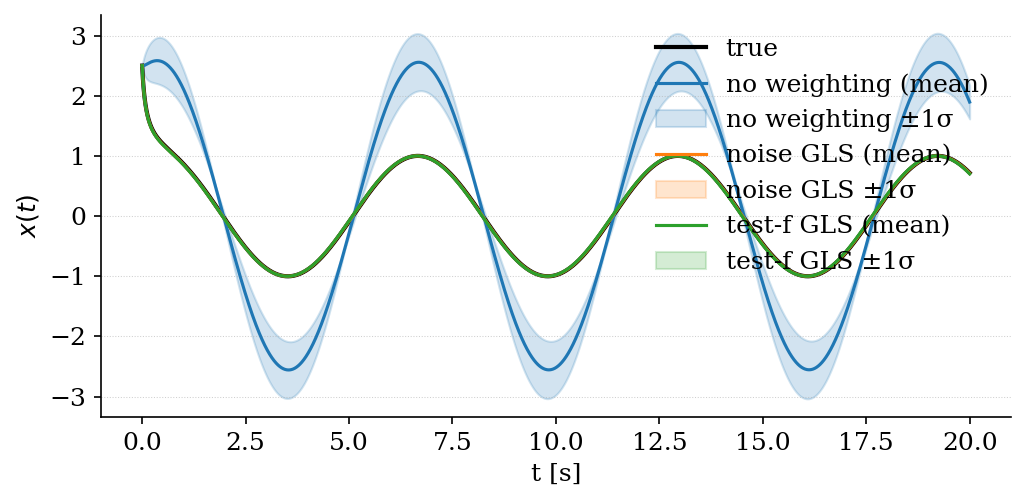

In [ ]:
# ------------------------------------------------------------
# Plot forecast envelopes (x-component)
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 3.5), dpi=150)

ax.plot(t_pred, traj_true[:, 0],
        "k", linewidth=2.0, label="true")

# No weighting
ax.plot(t_pred, w_mean_std[:, 0],
        color="tab:blue", linewidth=1.5, label="no weighting (mean)")
ax.fill_between(
    t_pred,
    w_mean_std[:, 0] - w_std_std[:, 0],
    w_mean_std[:, 0] + w_std_std[:, 0],
    color="tab:blue", alpha=0.20,
    label="no weighting ±1σ"
)

# Noise GLS
ax.plot(t_pred, w_mean_noise[:, 0],
        color="tab:orange", linewidth=1.5, label="noise GLS (mean)")
ax.fill_between(
    t_pred,
    w_mean_noise[:, 0] - w_std_noise[:, 0],
    w_mean_noise[:, 0] + w_std_noise[:, 0],
    color="tab:orange", alpha=0.20,
    label="noise GLS ±1σ"
)

# Test-function GLS (ones)
ax.plot(t_pred, w_mean_ones[:, 0],
        color="tab:green", linewidth=1.5, label="test-f GLS (mean)")
ax.fill_between(
    t_pred,
    w_mean_ones[:, 0] - w_std_ones[:, 0],
    w_mean_ones[:, 0] + w_std_ones[:, 0],
    color="tab:green", alpha=0.20,
    label="test-f GLS ±1σ"
)

ax.set_xlabel("t [s]")
ax.set_ylabel(r"$x(t)$")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle=":", linewidth=0.5, alpha=0.6)
ax.legend(frameon=False, loc="upper right")

plt.tight_layout()
plt.show()


## 6. Monte Carlo Robustness Experiment

We now repeat the identification over many trajectories with random initial
conditions and heteroscedastic noise. For each run:

1. Simulate a clean Hopf trajectory.
2. Add heteroscedastic noise.
3. Fit the three weak libraries with smaller ensembles.
4. Average the ensemble coefficients per method and compute:
   - mean relative $L_1$ coefficient error,
   - $L_0$ support error.

Finally, we compare the distributions of these errors across runs.

In [14]:
# %%
# ------------------------------------------------------------
# Monte Carlo setup
# ------------------------------------------------------------
N_RUNS = 100          # adjust as needed
t1_mc = 10.0
t_eval_mc = np.arange(t0, t1_mc, dt)

rng_mc = np.random.default_rng(123)

rel_L1_std_runs,   rel_L1_noise_runs,   rel_L1_ones_runs   = [], [], []
L0_std_runs,       L0_noise_runs,       L0_ones_runs       = [], [], []

C_true_flat = true_coef_hopf.reshape(-1)

for run in tqdm(range(N_RUNS), desc="Monte Carlo Hopf"):
    # 1) Random initial condition
    u0_run = rng_mc.uniform(-2.0, 2.0, size=2)

    sol_run = solve_ivp(
        hopf, (t0, t1_mc), u0_run, t_eval=t_eval_mc,
        rtol=1e-12, atol=1e-12
    )
    U_run = sol_run.y.T  # (T, 2)

    # 2) Heteroscedastic noise (same model)
    r_run = np.linalg.norm(U_run, axis=1)
    d_run = np.abs(r_run - 1.0)

    sigma0 = 1e-2
    alpha  = 0.25
    variance_run = (sigma0 + alpha * d_run)**2
    variance_run = np.maximum(variance_run, 1e-10)
    std_run = np.sqrt(variance_run)

    noise_run = std_run[:, None] * rng_mc.standard_normal(size=U_run.shape)
    U_noisy_run = U_run + noise_run

    # 3) Weak libraries for this run
    XT_run = t_eval_mc[:, None]
    base_lib_run = ps.PolynomialLibrary(degree=3, include_bias=False)

    np.random.seed(run)
    weak_lib_run = WeakPDELibrary(
        function_library=base_lib_run,
        derivative_order=1,
        spatiotemporal_grid=XT_run,
        is_uniform=True,
        include_bias=False,
    )

    np.random.seed(run)
    weighted_weak_lib_noise_run = WeightedWeakPDELibrary(
        function_library=base_lib_run,
        derivative_order=1,
        spatiotemporal_grid=XT_run,
        spatiotemporal_weights=variance_run,
        is_uniform=True,
        include_bias=False,
    )

    np.random.seed(run)
    weighted_weak_lib_ones_run = WeightedWeakPDELibrary(
        function_library=base_lib_run,
        derivative_order=1,
        spatiotemporal_grid=XT_run,
        spatiotemporal_weights=np.ones_like(variance_run),
        is_uniform=True,
        include_bias=False,
    )

    # 4) Fit SINDy models (smaller ensembles for speed)
    opt_std_run   = ps.EnsembleOptimizer(ps.STLSQ(threshold=0.5),
                                         bagging=True, n_models=20)
    opt_noise_run = ps.EnsembleOptimizer(ps.STLSQ(threshold=0.5),
                                         bagging=True, n_models=20)
    opt_ones_run  = ps.EnsembleOptimizer(ps.STLSQ(threshold=0.5),
                                         bagging=True, n_models=20)

    model_std_run   = ps.SINDy(feature_library=weak_lib_run,
                               optimizer=opt_std_run)
    model_noise_run = ps.SINDy(feature_library=weighted_weak_lib_noise_run,
                               optimizer=opt_noise_run)
    model_ones_run  = ps.SINDy(feature_library=weighted_weak_lib_ones_run,
                               optimizer=opt_ones_run)

    model_std_run.fit(U_noisy_run, t=t_eval_mc)
    model_noise_run.fit(U_noisy_run, t=t_eval_mc)
    model_ones_run.fit(U_noisy_run, t=t_eval_mc)

    # 5) Aggregate ensemble coefficients for this run (average over models)
    C_std_run   = np.mean(np.stack(opt_std_run.coef_list,   axis=0), axis=0).reshape(-1)
    C_noise_run = np.mean(np.stack(opt_noise_run.coef_list, axis=0), axis=0).reshape(-1)
    C_ones_run  = np.mean(np.stack(opt_ones_run.coef_list,  axis=0), axis=0).reshape(-1)

    # L1 errors
    rel_L1_std_runs.append(
        relative_L1_error(C_std_run, C_true_flat)
    )
    rel_L1_noise_runs.append(
        relative_L1_error(C_noise_run, C_true_flat)
    )
    rel_L1_ones_runs.append(
        relative_L1_error(C_ones_run, C_true_flat)
    )

    # L0 support errors
    L0_std_runs.append(
        l0_support_error(C_std_run, C_true_flat)
    )
    L0_noise_runs.append(
        l0_support_error(C_noise_run, C_true_flat)
    )
    L0_ones_runs.append(
        l0_support_error(C_ones_run, C_true_flat)
    )

rel_L1_std_runs   = np.asarray(rel_L1_std_runs)
rel_L1_noise_runs = np.asarray(rel_L1_noise_runs)
rel_L1_ones_runs  = np.asarray(rel_L1_ones_runs)

L0_std_runs   = np.asarray(L0_std_runs,   dtype=int)
L0_noise_runs = np.asarray(L0_noise_runs, dtype=int)
L0_ones_runs  = np.asarray(L0_ones_runs,  dtype=int)

print("Mean relative L1 over runs (no weighting):     ", np.mean(rel_L1_std_runs))
print("Mean relative L1 over runs (noise GLS):        ", np.mean(rel_L1_noise_runs))
print("Mean relative L1 over runs (test-f GLS, ones): ", np.mean(rel_L1_ones_runs))

print("Mean L0 support error over runs (no weighting):     ", np.mean(L0_std_runs))
print("Mean L0 support error over runs (noise GLS):        ", np.mean(L0_noise_runs))
print("Mean L0 support error over runs (test-f GLS, ones): ", np.mean(L0_ones_runs))


Monte Carlo Hopf: 100%|██████████| 100/100 [00:36<00:00,  2.72it/s]

Mean relative L1 over runs (no weighting):      0.743747708558315
Mean relative L1 over runs (noise GLS):         0.04975142649968985
Mean relative L1 over runs (test-f GLS, ones):  0.14032412758870616
Mean L0 support error over runs (no weighting):      5.91
Mean L0 support error over runs (noise GLS):         0.25
Mean L0 support error over runs (test-f GLS, ones):  0.7


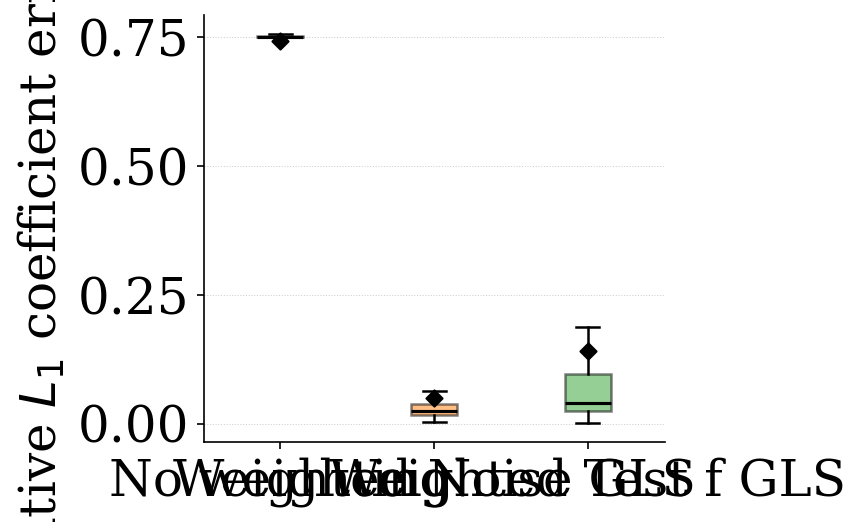

In [15]:
# ------------------------------------------------------------
# Monte Carlo boxplot of mean relative L1 errors
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 4), dpi=150)

data_mc   = [rel_L1_std_runs, rel_L1_noise_runs, rel_L1_ones_runs]
labels_mc = ["No weighting", "Weighted Noise GLS", "Weighted Test f GLS"]
means_mc  = [np.mean(d) for d in data_mc]

bp = ax.boxplot(
    data_mc,
    labels=labels_mc,
    showfliers=False,
    patch_artist=True,
    medianprops=dict(color="black", linewidth=1.5),
    boxprops=dict(linewidth=1.2),
    whiskerprops=dict(linewidth=1.2),
    capprops=dict(linewidth=1.2),
)

colors_mc = ["tab:blue", "tab:orange", "tab:green"]
for patch, c in zip(bp["boxes"], colors_mc):
    patch.set_facecolor(c)
    patch.set_alpha(0.5)

for x, m in zip([1, 2, 3], means_mc):
    ax.scatter(x, m, marker="D", color="black", s=30, zorder=3)

ax.set_ylabel(r"Mean relative $L_1$ coefficient error (per run)")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle=":", linewidth=0.5, alpha=0.6)

plt.tight_layout()
plt.show()


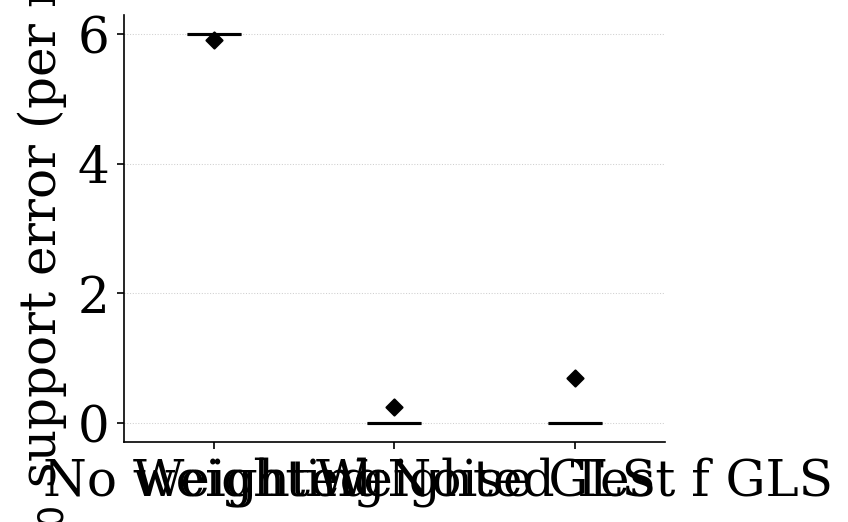

In [16]:
# ------------------------------------------------------------
# Monte Carlo boxplot of L0 support errors
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 4), dpi=150)

data_L0_mc   = [L0_std_runs, L0_noise_runs, L0_ones_runs]
labels_L0_mc = ["No weighting", "Weighted Noise GLS", "Weighted Test f GLS"]
means_L0_mc  = [np.mean(d) for d in data_L0_mc]

bp = ax.boxplot(
    data_L0_mc,
    labels=labels_L0_mc,
    showfliers=False,
    patch_artist=True,
    medianprops=dict(color="black", linewidth=1.5),
    boxprops=dict(linewidth=1.2),
    whiskerprops=dict(linewidth=1.2),
    capprops=dict(linewidth=1.2),
)

colors_L0_mc = ["tab:blue", "tab:orange", "tab:green"]
for patch, c in zip(bp["boxes"], colors_L0_mc):
    patch.set_facecolor(c)
    patch.set_alpha(0.5)

for x, m in zip([1, 2, 3], means_L0_mc):
    ax.scatter(x, m, marker="D", color="black", s=30, zorder=3)

ax.set_ylabel(r"$L_0$ support error (per run)")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle=":", linewidth=0.5, alpha=0.6)

plt.tight_layout()
plt.show()


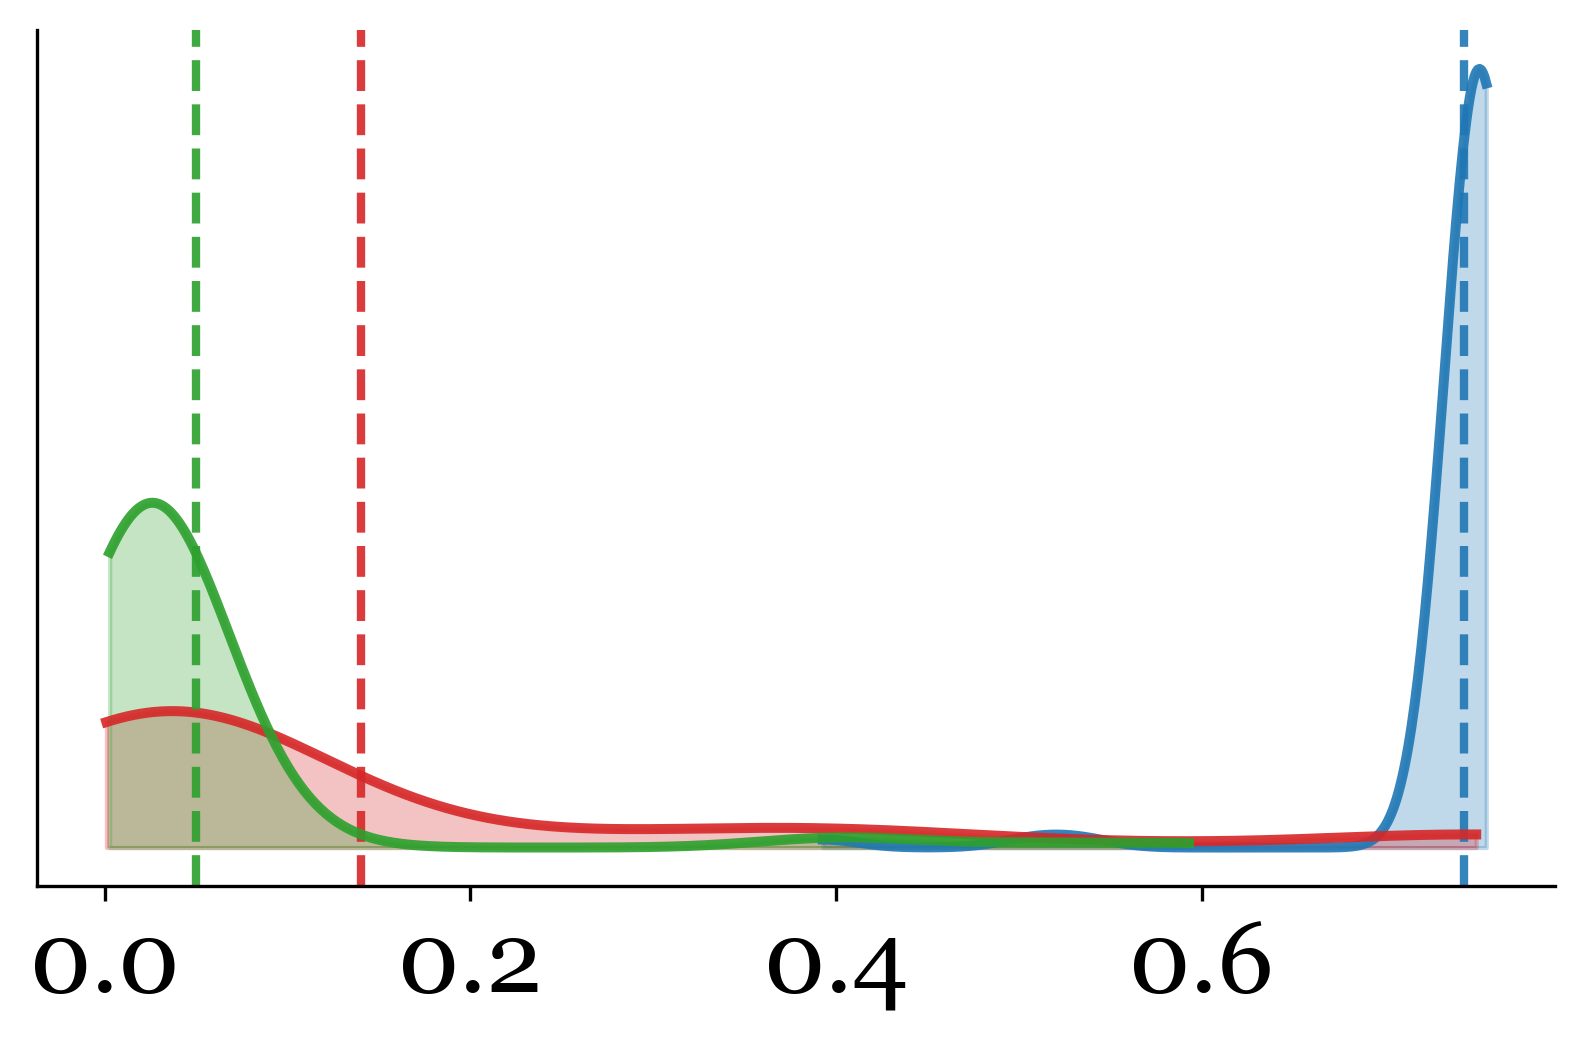

In [17]:
from scipy.stats import gaussian_kde

# --------------------------------------------------------------------
# Publication-quality Density Plot: Accuracy (relative L1)
# --------------------------------------------------------------------

plt.rcParams.update({
    "font.family": "Georgia",
    "font.size": 24,
})

rel_L1_all = [
    rel_L1_std_runs,
    rel_L1_ones_runs,
    rel_L1_noise_runs
]

colors = ["#1f77b4", "#d62728", "#2ca02c"]  # blue, red, green

fig, ax = plt.subplots(figsize=(6, 4), dpi=300)

# KDE curves + mean lines
for data, color in zip(rel_L1_all, colors):

    # KDE
    kde = gaussian_kde(data)
    x_eval = np.linspace(min(data), max(data), 400)
    y_eval = kde(x_eval)

    ax.plot(x_eval, y_eval, color=color, lw=2.4, alpha=0.9)
    ax.fill_between(x_eval, y_eval, alpha=0.28, color=color)

    # Mean vertical line
    mean_val = np.mean(data)
    ax.axvline(mean_val, linestyle="--", color=color, lw=2.0, alpha=0.9)

# No x-ticks (legend added externally)
ax.set_yticks([])

# ax.set_ylabel(r"$L_1$ error")

# Aesthetics
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle=":", linewidth=0.6, alpha=0.6)

plt.tight_layout()
plt.show()


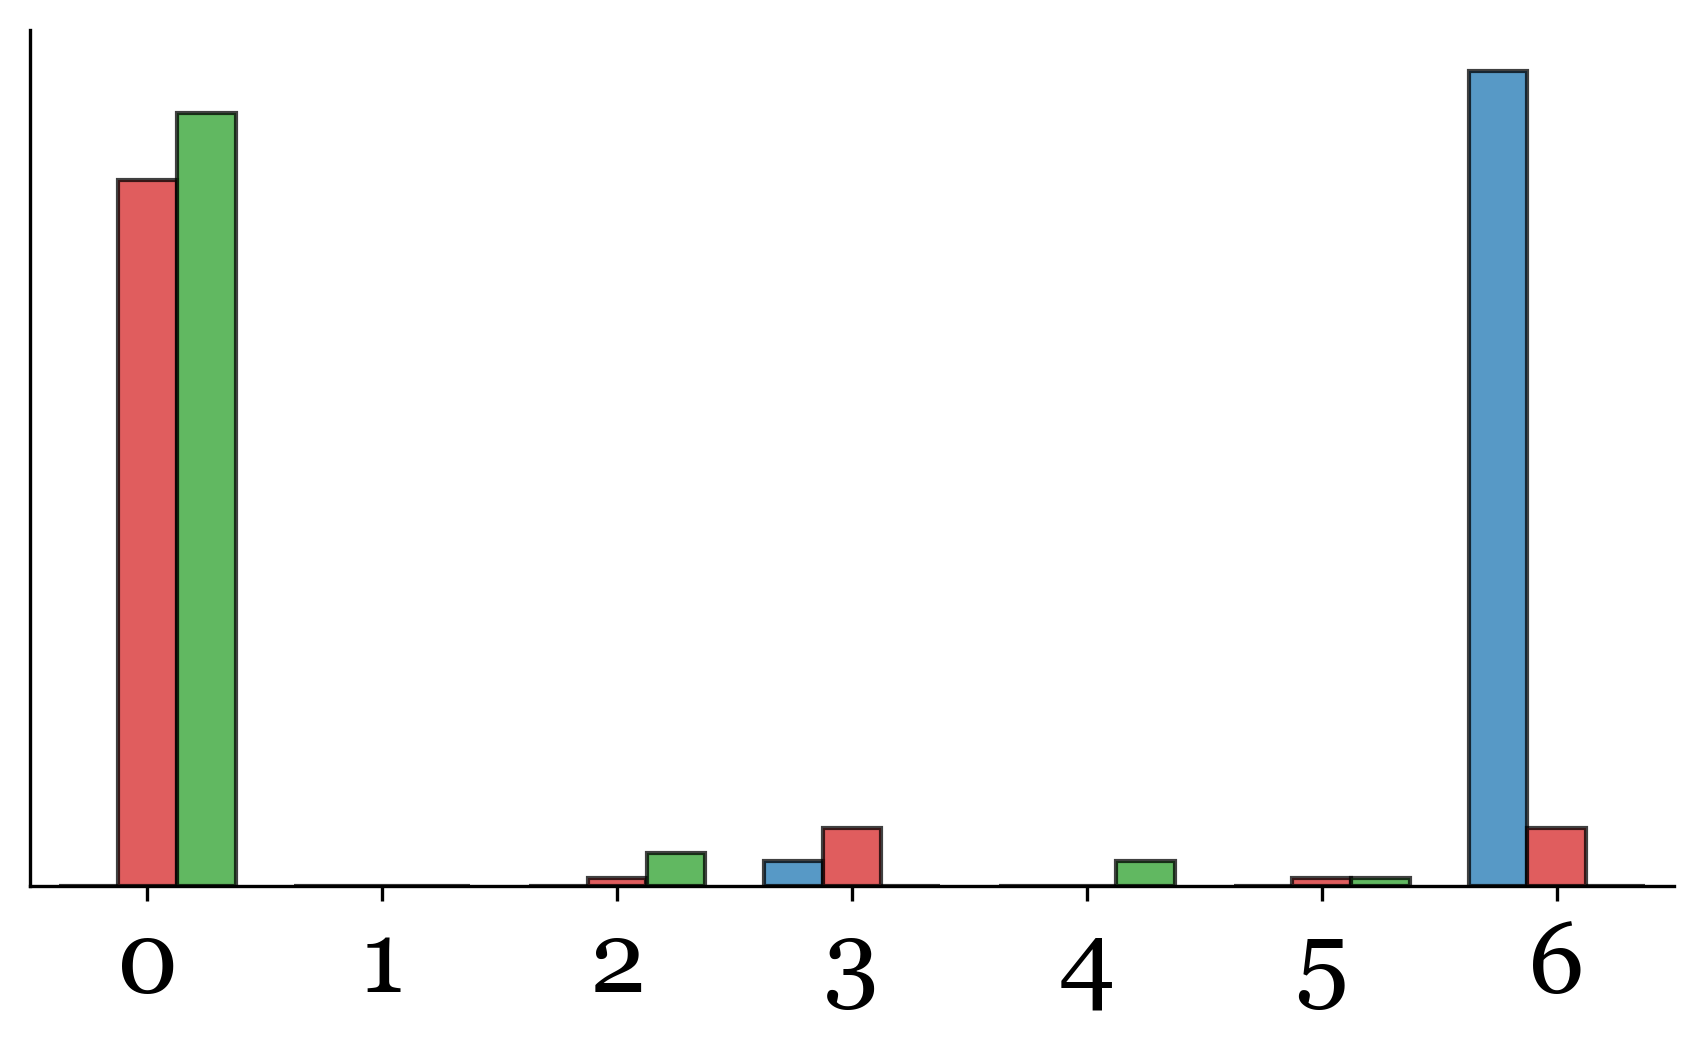

In [18]:
# --------------------------------------------------------------------
# Publication-quality Plot: L0 error distribution (grouped bar plot)
# --------------------------------------------------------------------

plt.rcParams.update({
    "font.family": "Georgia",
    "font.size": 24,
})

# Convert arrays
L0_std  = np.asarray(L0_std_runs)
L0_var  = np.asarray(L0_ones_runs)
L0_ones = np.asarray(L0_noise_runs)

# Maximum L0 across all methods
k_max = int(max(L0_std.max(), L0_var.max(), L0_ones.max()))
k_vals = np.arange(0, k_max + 1, dtype=int)

# Count occurrences of each L0 error value
counts_std  = np.bincount(L0_std,  minlength=k_max + 1)
counts_var  = np.bincount(L0_var,  minlength=k_max + 1)
counts_ones = np.bincount(L0_ones, minlength=k_max + 1)

# Colors used in earlier figures
colors = ["#1f77b4", "#d62728", "#2ca02c"]  # blue, red, green
width  = 0.25

fig, ax = plt.subplots(figsize=(6.2, 4.0), dpi=300)

# Grouped bars
ax.bar(k_vals - width,
       counts_std,
       width=width,
       color=colors[0],
       alpha=0.75,
       edgecolor="black")

ax.bar(k_vals,
       counts_var,
       width=width,
       color=colors[1],
       alpha=0.75,
       edgecolor="black")

ax.bar(k_vals + width,
       counts_ones,
       width=width,
       color=colors[2],
       alpha=0.75,
       edgecolor="black")

# Axis labels
# ax.set_xlabel(r"$L_0$ support mismatch")
# ax.set_ylabel("Frequency")
ax.set_xticks(k_vals)
ax.set_yticks([])
ax.set_xlim(-0.5, k_max + 0.5)

# No legend (you will add it externally)
# ax.legend(...)

# Aesthetics
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle=":", linewidth=0.6, alpha=0.6)

plt.tight_layout()
plt.show()
